# Blocking cross-modal attention routes

**Input:** two GQA attribute questions with target shirt boxes. **Model:** LLaVA-1.5-7B. **Tool:** Attention Knockout. This intervention sets selected key→query attention logits to negative infinity before softmax, jointly in a centered nine-layer window.

**Run mode:** the default cells replay real completed model measurements from `snapshots/`, using the public library visualization API. Saved outputs are retained. Set `RERUN = True` only after installing the model dependencies and configuring the optional run below. These examples are demonstrations, not dataset-level reproductions.

In [1]:
from pathlib import Path
import sys, json, os
ROOT = next(parent for parent in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
            if (parent / "demos" / "common.py").is_file() and (parent / "pyproject.toml").is_file())
sys.path[:0] = [str(ROOT), str(ROOT / "src")]
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, HTML, display
from vlm_probing import Prober
from vlm_probing.visualization import (plot_input, plot_lens_heatmap, plot_attention_comparison,
                                       plot_causal_heatmap, plot_intervention_curves)
from demos.common import ASSETS, load_snapshot, load_image, show_figure, gqa_input, target_ranks
RERUN = False  # Keep False for the bundled, genuinely measured offline results.
print("Offline replay of archived model measurements; no inference or training.")

Offline replay of archived model measurements; no inference or training.


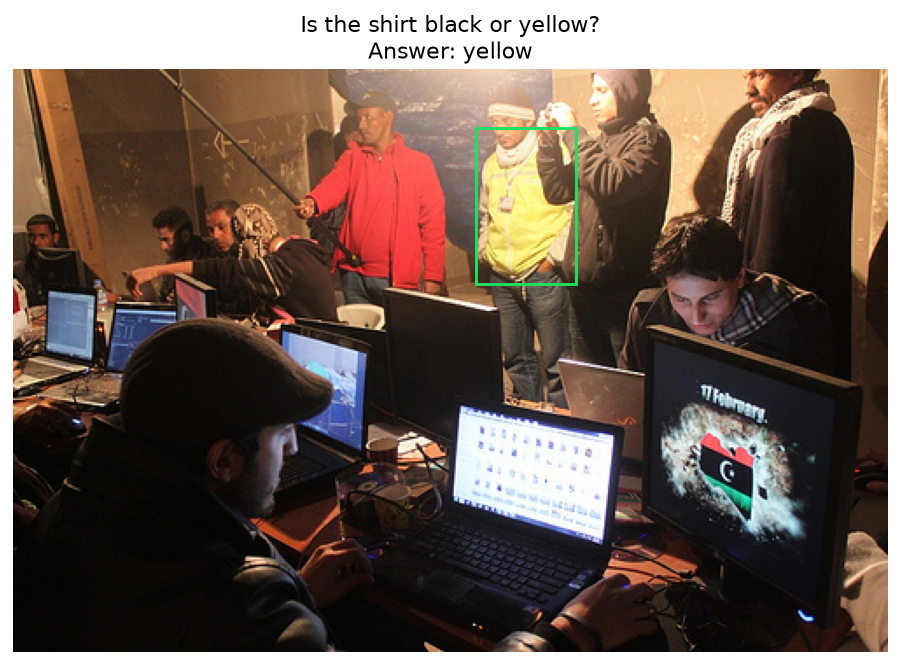

Native generated answer: Yellow


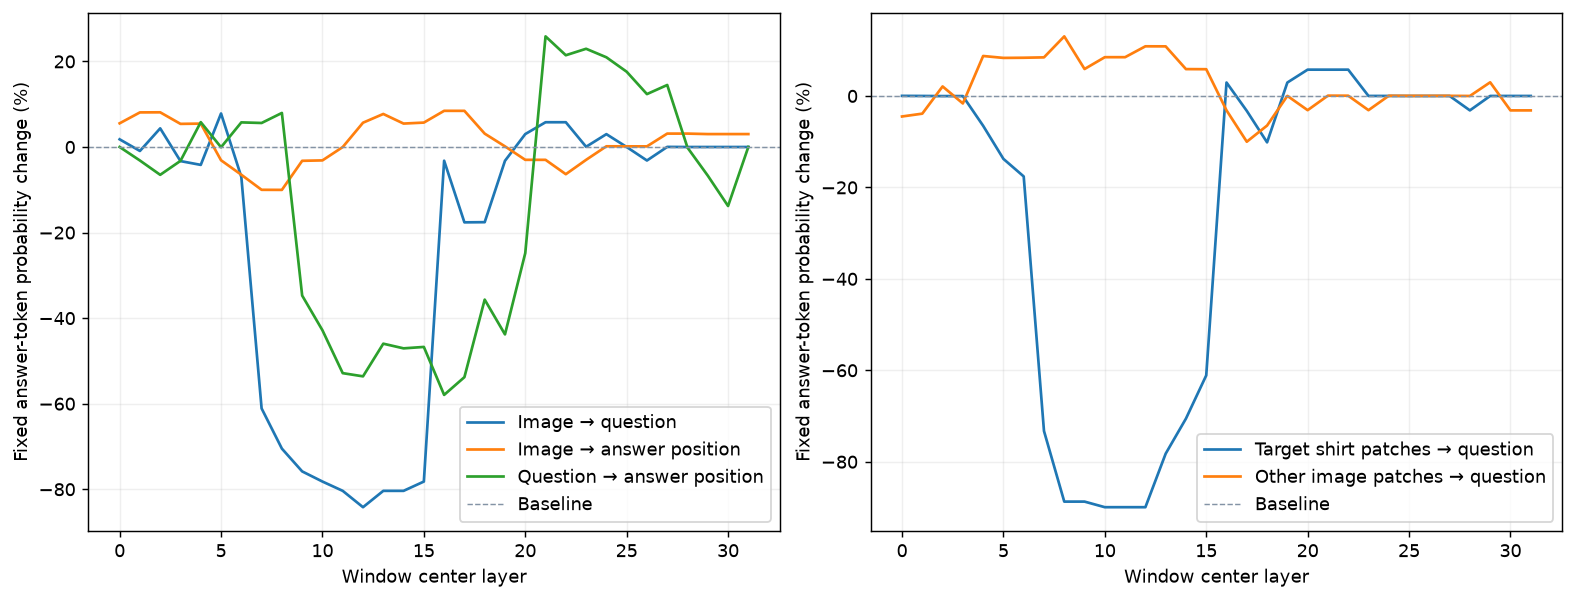

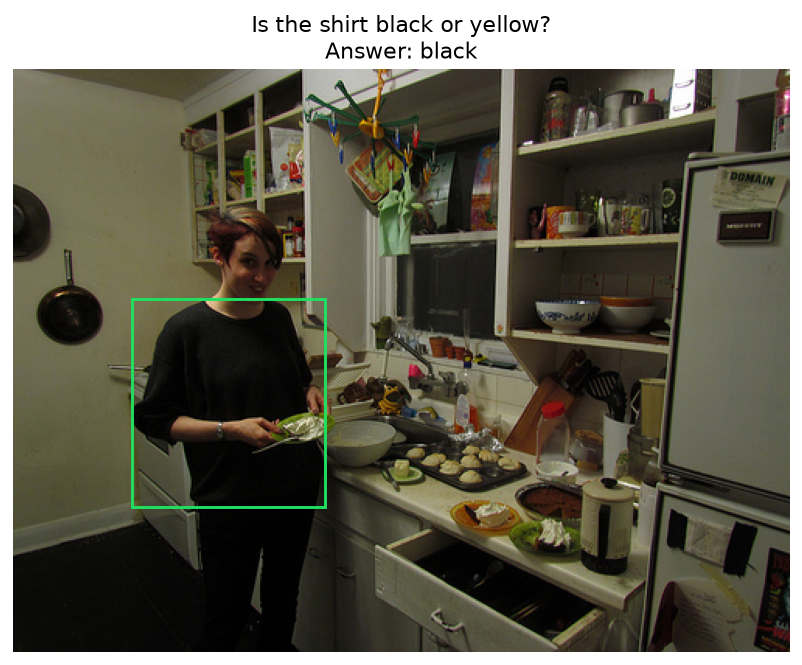

Native generated answer: Black


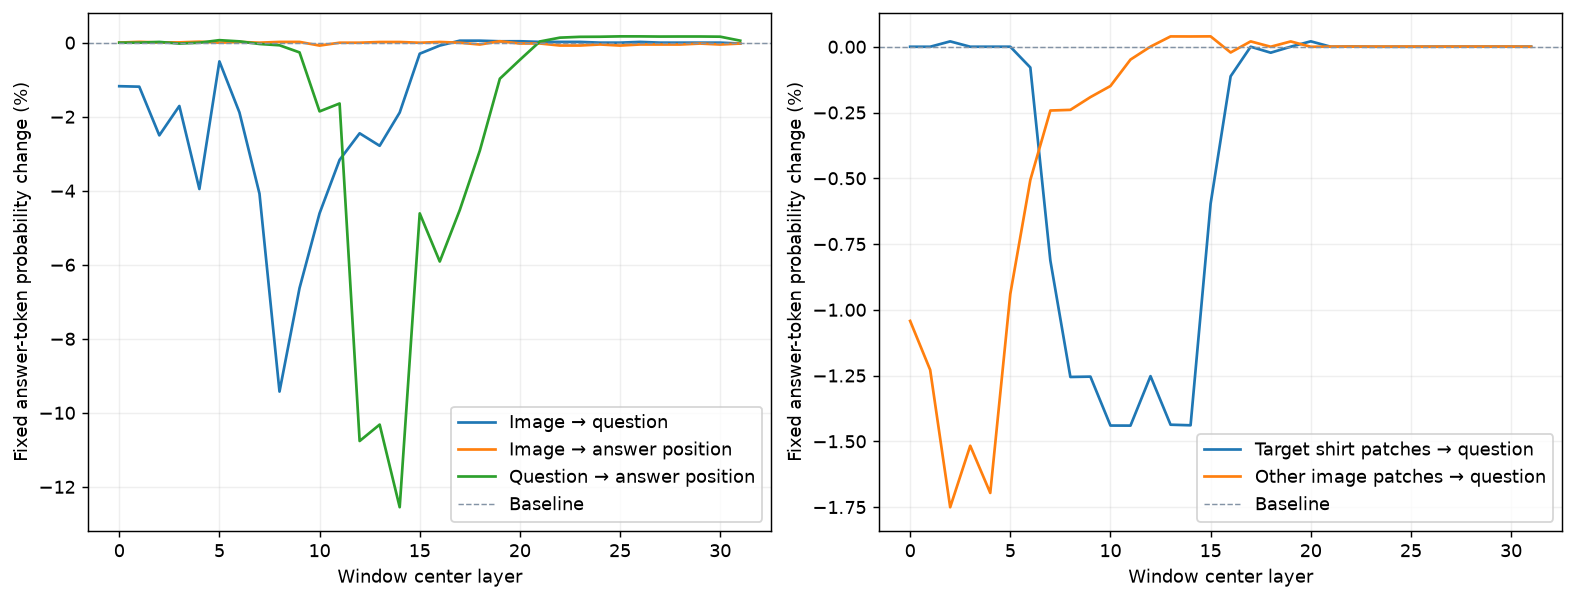

In [2]:
records = [load_snapshot(f"attention_knockout/{sample}.json") for sample in ("07302654", "19225230")]
for record in records:
    sample = record["sample"]
    ax = plot_input(load_image(sample["image_path"]), prompt=sample["question"], answer=sample["answer"],
                    bounding_boxes=[sample["bbox_xywh"]])
    show_figure(ax.figure)
    print("Native generated answer:", record["baseline"]["generated_answer"])
    fig, axes = plt.subplots(1, 2, figsize=(12,4.5), constrained_layout=True)
    for ax, selected in zip(axes, [["image_to_question","image_to_last","question_to_last"],
                                 ["target_to_question","other_to_question"]]):
        curves = {scan["label"]:{"x":scan["centers"],"y":scan["relative_change_percent"]}
                  for scan in record["scan"] if scan["path"] in selected}
        plot_intervention_curves(curves, ax=ax, baseline=0, xlabel="Window center layer",
                                  ylabel="Fixed answer-token probability change (%)")
    show_figure(fig)

**How to read:** zero means unchanged support for the fixed first answer token; negative values mean reduced support. Each point jointly blocks a nine-layer window, clipped at the decoder boundaries. The target-versus-other comparison uses all patches in each region: the regions differ in size and should not be treated as an area-matched localization score. This first-token probability differs from the complete-answer metric in the lens and attribution demos.

## Optional new model run

This cell is deliberately opt-in. `VLM_PROBING_MODEL` selects a Hugging Face model ID or local checkpoint; `VLM_PROBING_DEVICE` selects the device. Hugging Face uses its normal cache (`HF_HOME` can relocate it). Rerunning performs fresh forwards and may need a GPU. An architecture-specific input adapter may be needed when changing the model; inspect `probe.describe()` first.

In [3]:
if RERUN:
    from demos.runtime import bind_model, gqa_case
    from demos.inputs import FixedAnswerProbability, layer_window
    probe, processor, device = bind_model("llava-hf/llava-1.5-7b-hf")
    base, masks, info = gqa_case(probe, processor, records[0]["sample"], ASSETS / "images", score_answer=False)
    token_id = processor.tokenizer.encode(records[0]["sample"]["answer"].capitalize(), add_special_tokens=False)[0]
    metric = FixedAnswerProbability(token_id)
    layers = sorted(probe.spec.attention_scores)
    curves = {}
    for label, query, key in [("Image to question","question","image"),
                               ("Image to prediction","last","image"),
                               ("Question to prediction","last","question"),
                               ("Target to question","question","target"),
                               ("Other to question","question","other")]:
        points = []
        for center in layers:
            result = probe.causal.knockout(layers=layer_window(center,len(layers),9),
                     queries=masks[query], keys=masks[key], joint=True).run(base, metric=metric)
            baseline = float(result.tensors["baseline_score"].item())
            changed = float(result.tensors["intervention_score"].item())
            points.append(100*(changed/baseline-1))
        curves[label] = {"x":layers,"y":points}
    ax = plot_intervention_curves(curves, baseline=0, xlabel="Window center layer",
                                  ylabel="Fixed answer-token probability change (%)")
    show_figure(ax.figure)
else:
    print("Fresh joint-window scans skipped.")

Fresh joint-window scans skipped.


## Sources and interpretation

**Paper:** [Cross-modal Information Flow in Multimodal Large Language Models](https://arxiv.org/abs/2411.18620), Sections 3.2, 5–6; Figures 3–5; Appendix B. **Data:** [author GQA subset](https://github.com/FightingFighting/cross-modal-information-flow-in-MLLM/tree/main/datasets), [original images](https://cs.stanford.edu/people/dorarad/gqa/download.html). Question 07302654 / image 2341576 (yellow), question 19225230 / image 2342134 (black).

Bundled image and data attribution is listed in [README.md](README.md) and [image notices](assets/images/SOURCE_NOTICES.md). Model checkpoints and fitted lens artifacts are not included.